# Cox-PH and DeepSurv

In this notebook we will train the [Cox-PH method](http://jmlr.org/papers/volume20/18-424/18-424.pdf), also known as [DeepSurv](https://bmcmedresmethodol.biomedcentral.com/articles/10.1186/s12874-018-0482-1).
We will use the METABRIC data sets as an example

A more detailed introduction to the `pycox` package can be found in [this notebook](https://nbviewer.jupyter.org/github/havakv/pycox/blob/master/examples/01_introduction.ipynb) about the `LogisticHazard` method.

The main benefit Cox-CC (and the other Cox methods) has over Logistic-Hazard is that it is a continuous-time method, meaning we do not need to discretize the time scale.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn_pandas import DataFrameMapper

import torch
import torchtuples as tt

from pycox.datasets import metabric, support, gbsg
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

In [103]:
## Uncomment to install `sklearn-pandas`
! pip install sklearn-pandas
! pip install scikit-learn

zsh:1: command not found: pip
zsh:1: command not found: pip


In [104]:
np.random.seed(1234)
_ = torch.manual_seed(123)

## Dataset

We load the METABRIC data set and split in train, test and validation.

In [105]:
df_train = metabric.read_df()
df_test = df_train.sample(frac=0.2)
df_train = df_train.drop(df_test.index)
df_val = df_train.sample(frac=0.2)
df_train = df_train.drop(df_val.index)

In [130]:
metabric.read_df().sample(n=10)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,duration,event
1741,6.464291,5.958040,10.648099,5.596418,0.0,0.0,0.0,1.0,47.919998,99.966667,1
1845,5.538934,7.259114,10.365037,5.738034,1.0,1.0,0.0,1.0,72.440002,197.833328,1
1636,5.548498,8.633205,10.592564,5.472196,0.0,0.0,0.0,1.0,58.369999,177.600006,0
1825,5.955439,7.416153,10.294530,5.655762,1.0,1.0,0.0,1.0,68.160004,130.466660,0
87,6.220673,5.689575,10.689259,5.857145,1.0,0.0,0.0,1.0,42.680000,114.333336,0
531,5.798812,5.924979,11.527822,5.649197,0.0,0.0,0.0,1.0,70.900002,74.933334,1
1815,5.618859,7.274062,10.637414,5.946522,1.0,0.0,0.0,1.0,66.849998,234.533340,1
1724,6.392218,6.768040,11.299891,5.353434,1.0,0.0,0.0,1.0,45.810001,122.500000,0
1828,6.008595,5.480888,9.580607,5.655789,1.0,1.0,0.0,1.0,83.889999,39.166668,1
1107,5.811359,5.420855,10.022382,5.790741,0.0,0.0,0.0,1.0,59.470001,77.666664,1


In [131]:
support.read_df().sample(n=10)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,duration,event
8221,71.821960,0.0,3.0,2.0,0.0,0.0,2.0,60.0,64.0,24.0,35.500000,138.0,5.699219,1.000000,1977.0,0
6895,71.788940,0.0,4.0,1.0,1.0,0.0,1.0,82.0,76.0,20.0,35.796879,144.0,5.799805,1.799805,540.0,1
825,38.192989,0.0,1.0,1.0,0.0,0.0,1.0,89.0,80.0,12.0,36.500000,123.0,4.899414,1.899902,290.0,1
1523,77.031982,1.0,0.0,1.0,0.0,0.0,1.0,108.0,106.0,32.0,36.093750,134.0,11.500000,0.899902,4.0,1
921,63.638981,0.0,1.0,1.0,0.0,0.0,1.0,117.0,100.0,21.0,37.593750,146.0,11.099609,3.599609,758.0,1
8768,68.254936,1.0,2.0,1.0,0.0,0.0,1.0,71.0,176.0,8.0,36.500000,131.0,26.097656,7.000000,9.0,1
7360,50.367981,0.0,1.0,1.0,0.0,0.0,0.0,103.0,96.0,24.0,38.195309,138.0,11.099609,1.199951,427.0,1
2003,63.832981,1.0,0.0,1.0,0.0,0.0,1.0,68.0,75.0,20.0,36.398441,134.0,29.597656,1.399902,8.0,1
5793,74.482971,0.0,2.0,1.0,0.0,0.0,1.0,111.0,60.0,32.0,36.796879,142.0,6.899414,1.599854,2012.0,0
795,33.012970,1.0,2.0,1.0,1.0,0.0,1.0,133.0,100.0,8.0,38.195309,146.0,10.500000,10.798828,68.0,1


## Feature transforms
We have 9 covariates, in addition to the durations and event indicators.

We will standardize the 5 numerical covariates, and leave the binary variables as is. As variables needs to be of type `'float32'`, as this is required by pytorch.

In [107]:
cols_standardize = ['x0', 'x1', 'x2', 'x3', 'x8']
cols_leave = ['x4', 'x5', 'x6', 'x7']

standardize = [([col], StandardScaler()) for col in cols_standardize]
leave = [(col, None) for col in cols_leave]

x_mapper = DataFrameMapper(standardize + leave)

In [108]:
x_train = x_mapper.fit_transform(df_train).astype('float32')
x_val = x_mapper.transform(df_val).astype('float32')
x_test = x_mapper.transform(df_test).astype('float32')

In [109]:
x_train

array([[-0.6789899 ,  1.5512409 ,  0.01523471, ...,  1.        ,
         0.        ,  1.        ],
       [-1.0300117 ,  3.2727063 , -0.41635963, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.4767839 , -0.85106283, -1.5497689 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.3512742 , -0.9187757 ,  2.4904273 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.65737414, -0.8210056 ,  0.63686645, ...,  0.        ,
         0.        ,  1.        ],
       [-0.5448622 , -0.7461271 , -0.79741466, ...,  1.        ,
         0.        ,  0.        ]], shape=(1218, 9), dtype=float32)

We need no label transforms

In [110]:
get_target = lambda df: (df['duration'].values, df['event'].values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = x_val, y_val

## Neural net

We create a simple MLP with two hidden layers, ReLU activations, batch norm and dropout. 
Here, we just use the `torchtuples.practical.MLPVanilla` net to do this.

Note that we set `out_features` to 1, and that we have not `output_bias`.

In [111]:
in_features = x_train.shape[1]
num_nodes = [32, 32]
out_features = 1
batch_norm = True
dropout = 0.1
output_bias = False

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm,
                              dropout, output_bias=output_bias)

## Training the model

To train the model we need to define an optimizer. You can choose any `torch.optim` optimizer, but here we instead use one from `tt.optim` as it has some added functionality.
We use the `Adam` optimizer, but instead of choosing a learning rate, we will use the scheme proposed by [Smith 2017](https://arxiv.org/pdf/1506.01186.pdf) to find a suitable learning rate with `model.lr_finder`. See [this post](https://towardsdatascience.com/finding-good-learning-rate-and-the-one-cycle-policy-7159fe1db5d6) for an explanation.

In [112]:
model = CoxPH(net, tt.optim.Adam)

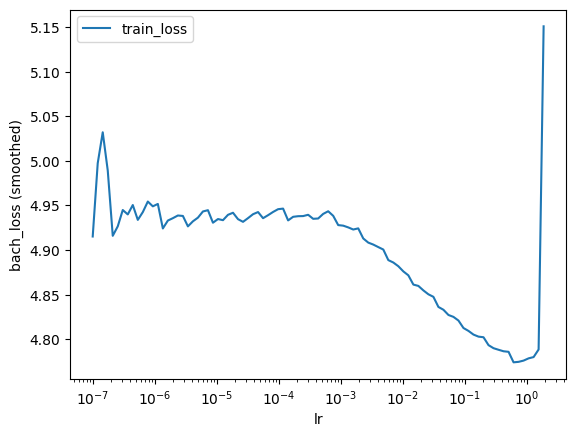

In [113]:
batch_size = 256
lrfinder = model.lr_finder(x_train, y_train, batch_size, tolerance=10)
_ = lrfinder.plot()

In [114]:
lrfinder.get_best_lr()

np.float64(0.0613590727341321)

Often, this learning rate is a little high, so we instead set it manually to 0.01

In [115]:
model.optimizer.set_lr(0.01)

We include the `EarlyStopping` callback to stop training when the validation loss stops improving. After training, this callback will also load the best performing model in terms of validation loss.

In [116]:
epochs = 512
callbacks = [tt.callbacks.EarlyStopping()]
verbose = True

In [117]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val, val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.7731,	val_loss: 3.9381
1:	[0s / 0s],		train_loss: 4.6650,	val_loss: 3.9277
2:	[0s / 0s],		train_loss: 4.6280,	val_loss: 3.9477
3:	[0s / 0s],		train_loss: 4.6059,	val_loss: 3.9304
4:	[0s / 0s],		train_loss: 4.6073,	val_loss: 3.9153
5:	[0s / 0s],		train_loss: 4.5785,	val_loss: 3.9085
6:	[0s / 0s],		train_loss: 4.5815,	val_loss: 3.9275
7:	[0s / 0s],		train_loss: 4.5703,	val_loss: 3.9373
8:	[0s / 0s],		train_loss: 4.5590,	val_loss: 3.9120
9:	[0s / 0s],		train_loss: 4.5697,	val_loss: 3.9082
10:	[0s / 0s],		train_loss: 4.5481,	val_loss: 3.9167
11:	[0s / 0s],		train_loss: 4.5723,	val_loss: 3.9299
12:	[0s / 0s],		train_loss: 4.5516,	val_loss: 3.9354
13:	[0s / 0s],		train_loss: 4.5546,	val_loss: 3.9446
14:	[0s / 0s],		train_loss: 4.5350,	val_loss: 3.9469
15:	[0s / 0s],		train_loss: 4.5411,	val_loss: 3.9349
16:	[0s / 0s],		train_loss: 4.5479,	val_loss: 3.9465
17:	[0s / 0s],		train_loss: 4.5435,	val_loss: 3.9697
18:	[0s / 0s],		train_loss: 4.5487,	val_loss: 3.9625
19:

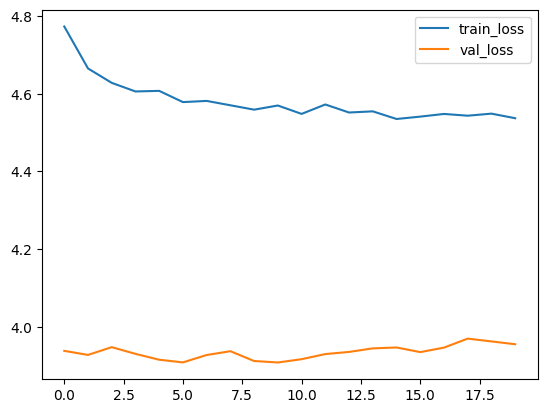

In [118]:
_ = log.plot()

We can get the partial log-likelihood

In [119]:
model.partial_log_likelihood(*val).mean()

np.float32(-4.9757557)

## Prediction

For evaluation we first need to obtain survival estimates for the test set.
This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

However, as `CoxPH` is semi-parametric, we first need to get the non-parametric baseline hazard estimates with `compute_baseline_hazards`. 

Note that for large datasets the `sample` argument can be used to estimate the baseline hazard on a subset.

In [120]:
_ = model.compute_baseline_hazards()

In [121]:
surv = model.predict_surv_df(x_test)

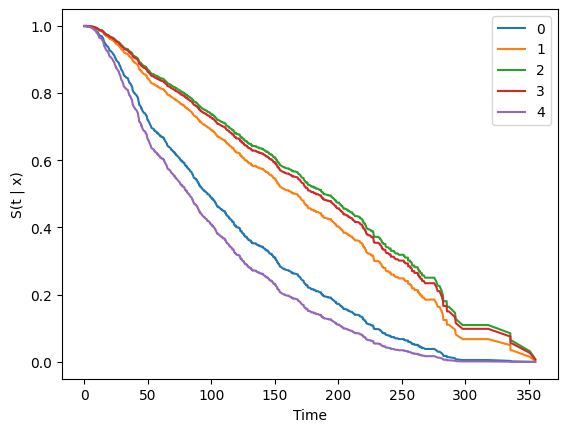

In [122]:
surv.iloc[:, :5].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

## Evaluation

We can use the `EvalSurv` class for evaluation the concordance, brier score and binomial log-likelihood. Setting `censor_surv='km'` means that we estimate the censoring distribution by Kaplan-Meier on the test set.

In [123]:
ev = EvalSurv(surv, durations_test, events_test, censor_surv='km')

In [124]:
ev.concordance_td()

0.6548355653500594

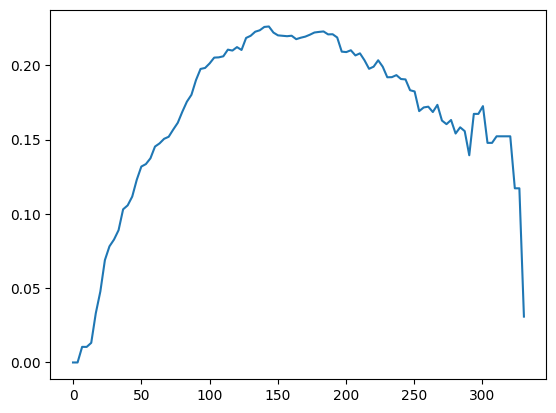

In [125]:
time_grid = np.linspace(durations_test.min(), durations_test.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [126]:
ev.integrated_brier_score(time_grid)

np.float64(0.16741496839338837)

In [127]:
import scipy
print(scipy.__version__)

1.16.0


In [128]:
ev.integrated_nbll(time_grid)

np.float64(0.4966329351754217)